# Лабораторная работа 12

Тема: **Vanilla GAN для генерации цифр MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваше понимание задачи GAN (если не знаетет, что такое GAN - можно гуглить и спрашивать LLM)

Перед запуском кода опишите текущее понимание (8–12 предложений):

1. Для чего нужны генеративно‑состязательные сети (GAN) и чем их цель отличается от классической задачи классификации.  
2. Как вы интуитивно представляете «игру» генератора и дискриминатора: кто что пытается сделать и почему это неустойчивая задача.  
3. Каких визуальных артефактов вы ожидаете от **простого** Vanilla GAN на MNIST (размытость, странные гибриды цифр и т.п.).

Пишите своими словами, как если бы объясняли задачу одногруппнику.


In [1]:
intro_text = """1)Генеративно-состязательные сети нужны для генерации новых данных, похожих на обучающую выборку.
GAN отличаются от классификаторов тем, что создают новые примеры, иммитирующие реальные, а классификаторы учатся предсказывать класс.
GAN состоит из двух нейросетей генератора и дискриминатора.

2)"Игра" генератора и дискриминатора заключается в том, что генератор стремится обмануть дискриминатор,а дискриминатор пытается распознать фейк.
Генератор получает на вход случайный шум и пытается создать реалистичное изображение.
А дискриминатор получает как реальные, так и сгенерированные изображения и должен определить, какие из них настоящие.
Обучение можно считать неустойчивое именно за этой "игры", потому что если одна сеть становится устойчивой, то вторая теряет свои способности.
То есть генератор слишком сильный - дискриминатор теряет способности распознать фейк; дискриминатор сильный - генератор перестает обучаться.

3)Я ожидаю  от простого Vanilla GAN на MNIST такие артефакты, как размытие, нечетки контуры, гибридные цифры.
"""
print(intro_text)

1)Генеративно-состязательные сети нужны для генерации новых данных, похожих на обучающую выборку.
GAN отличаются от классификаторов тем, что создают новые примеры, иммитирующие реальные, а классификаторы учатся предсказывать класс.
GAN состоит из двух нейросетей генератора и дискриминатора.

2)"Игра" генератора и дискриминатора заключается в том, что генератор стремится обмануть дискриминатор,а дискриминатор пытается распознать фейк.
Генератор получает на вход случайный шум и пытается создать реалистичное изображение.
А дискриминатор получает как реальные, так и сгенерированные изображения и должен определить, какие из них настоящие.
Обучение можно считать неустойчивое именно за этой "игры", потому что если одна сеть становится устойчивой, то вторая теряет свои способности.
То есть генератор слишком сильный - дискриминатор теряет способности распознать фейк; дискриминатор сильный - генератор перестает обучаться.

3)Я ожидаю  от простого Vanilla GAN на MNIST такие артефакты, как размыти

## 2. Импорт, настройки и данные (MNIST)


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

import matplotlib.pyplot as plt
import numpy as np
import os

MY_SEED = 22  # при своих экспериментах можете поменять, но зафиксируйте в отчёте
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

# каталог для возможного сохранения картинок
os.makedirs("gan_samples", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # пиксели в [-1, 1]
])

batch_size = 64

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print("Размер train:", len(train_dataset))

Устройство: cuda
MY_SEED = 22
Размер train: 60000


Посмотрим на несколько реальных изображений, которые GAN должен научиться имитировать.


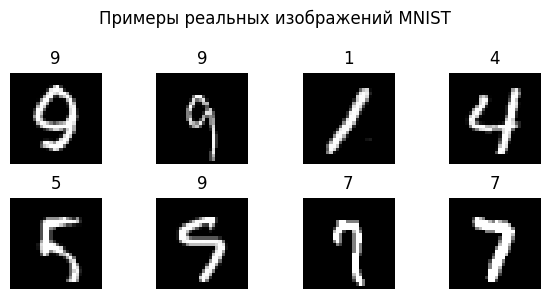

In [3]:
real_images, real_labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(real_images[i].squeeze(0), cmap="gray")
    plt.title(str(real_labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры реальных изображений MNIST")
plt.tight_layout()
plt.show()

### Мини‑комментарий по данным

Кратко (3–5 предложений) опишите:
- насколько, на ваш взгляд, легко/сложно генератору научиться имитировать такие цифры;  
- какие особенности рукописных цифр могут затруднить генерацию (разные стили, толщина линий и т.п.).


In [4]:
data_comment = """На мой взгляд, генератору должно быть относительно несложно имитировать такие цифры, потому что изображение небольшое и несложное.
Однако особенности рукописных цифр могут затруднить генерацию, так как одна и та же цифра может писаться по-разному.
Например, 7 пишется и с чертой, и без. Также в цифрах есть наклон, разная толщина.
Особенно сложными могут быть цифры с похожим стилем, например 3 и 5, 1 и 7, что может приводить к гибридным цифрам.
"""
print(data_comment)

На мой взгляд, генератору должно быть относительно несложно имитировать такие цифры, потому что изображение небольшое и несложное.
Однако особенности рукописных цифр могут затруднить генерацию, так как одна и та же цифра может писаться по-разному.
Например, 7 пишется и с чертой, и без. Также в цифрах есть наклон, разная толщина.
Особенно сложными могут быть цифры с похожим стилем, например 3 и 5, 1 и 7, что может приводить к гибридным цифрам.



## 3. Архитектура генератора и дискриминатора

Используем классический Vanilla GAN с полносвязными сетями:
- Генератор: принимает случайный шум `z` размерности 100 и выдаёт изображение 28×28 (через `tanh`, в диапазоне [-1, 1]);  
- Дискриминатор: принимает изображение 28×28 и выдаёт вероятность того, что оно "реальное".


In [5]:
z_dim = 50
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        img = img.view(-1, 1, 28, 28)
        return img


class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


G = Generator(z_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

print(G)
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, 

### Краткий анализ архитектуры

Ответьте в 4–6 предложениях:
- почему в генераторе используется `tanh` на выходе и совместим ли он с нормализацией входных данных;  
- зачем в дискриминаторе используется `LeakyReLU`, а не обычный `ReLU`.


In [6]:
arch_comment = """Так как у нас изображения нормализуются в диапазоне [-1, 1], функция активации tanh может хорошо согласоваться с ними, потому что тоже ограничивает значения пикселей в диапазоне [-1, 1].
Такое согласование помогает стабилизировать обучение и ускоряет сходимость модели.

В дискриминаторе используется LeakyReLU, потому что она пропускает небольшой отрицательный градиент для отрицательных значений.
Это предотвращает «умирание» нейронов.
Это делает обучение более стабильным.
"""
print(arch_comment)

Так как у нас изображения нормализуются в диапазоне [-1, 1], функция активации tanh может хорошо согласоваться с ними, потому что тоже ограничивает значения пикселей в диапазоне [-1, 1].
Такое согласование помогает стабилизировать обучение и ускоряет сходимость модели.

В дискриминаторе используется LeakyReLU, потому что она пропускает небольшой отрицательный градиент для отрицательных значений.
Это предотвращает «умирание» нейронов.
Это делает обучение более стабильным.



## 4. Функция потерь, оптимизаторы и фиксированный шум

Используем бинарную кросс‑энтропию и два оптимизатора Adam (для G и D).


In [7]:
criterion = nn.BCELoss()

# lr = 2e-4
beta1 = 0.5

opt_G = torch.optim.Adam(G.parameters(), lr=4e-4, betas=(beta1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(beta1, 0.999))

# фиксированный шум для отслеживания прогресса генератора
fixed_z = torch.randn(64, z_dim, device=device)
print("fixed_z shape:", fixed_z.shape)

fixed_z shape: torch.Size([64, 50])


## 5. Цикл обучения GAN с журналированием лоссов

На каждой итерации:

1. Обновляем дискриминатор: считаем лосс на реальных и сгенерированных изображениях.  
2. Обновляем генератор: генерируем фейки и стараемся заставить дискриминатор считать их реальными.


Эпоха 1/15 | loss_G=0.6807, loss_D=1.3488


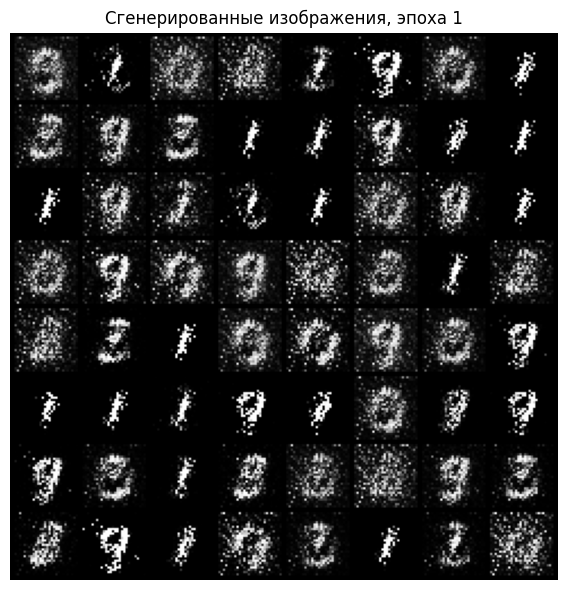

Эпоха 2/15 | loss_G=0.7956, loss_D=1.3275
Эпоха 3/15 | loss_G=0.8663, loss_D=1.3148
Эпоха 4/15 | loss_G=0.8634, loss_D=1.3114
Эпоха 5/15 | loss_G=0.8084, loss_D=1.3365


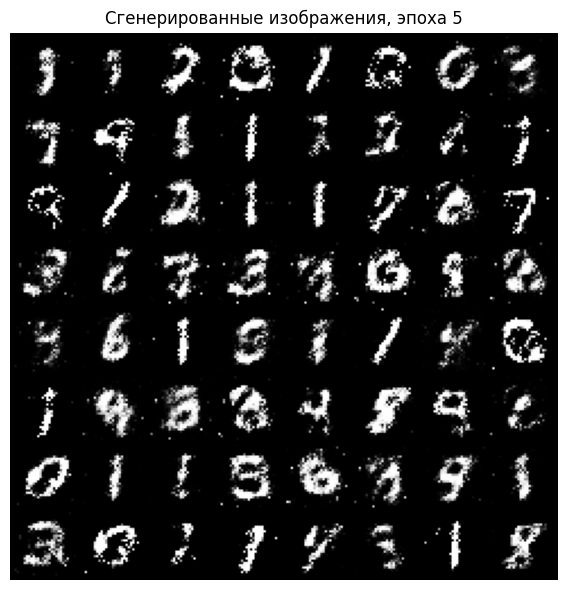

Эпоха 6/15 | loss_G=0.7856, loss_D=1.3498
Эпоха 7/15 | loss_G=0.7745, loss_D=1.3552
Эпоха 8/15 | loss_G=0.7642, loss_D=1.3614
Эпоха 9/15 | loss_G=0.7604, loss_D=1.3613
Эпоха 10/15 | loss_G=0.7583, loss_D=1.3616


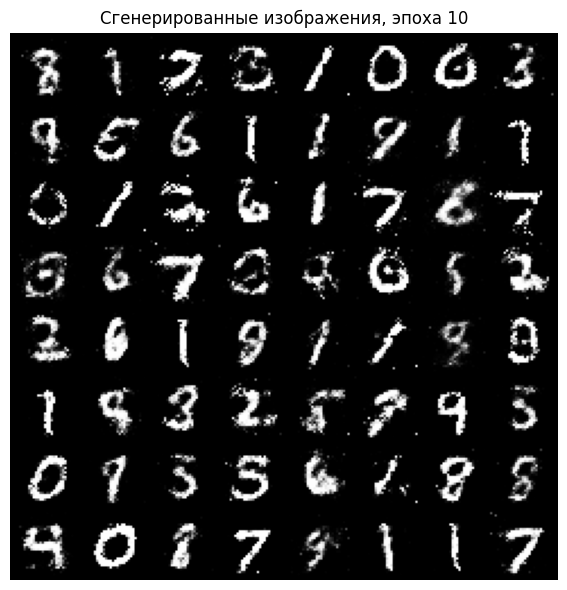

Эпоха 11/15 | loss_G=0.7559, loss_D=1.3629
Эпоха 12/15 | loss_G=0.7526, loss_D=1.3657
Эпоха 13/15 | loss_G=0.7486, loss_D=1.3673
Эпоха 14/15 | loss_G=0.7454, loss_D=1.3679
Эпоха 15/15 | loss_G=0.7471, loss_D=1.3677


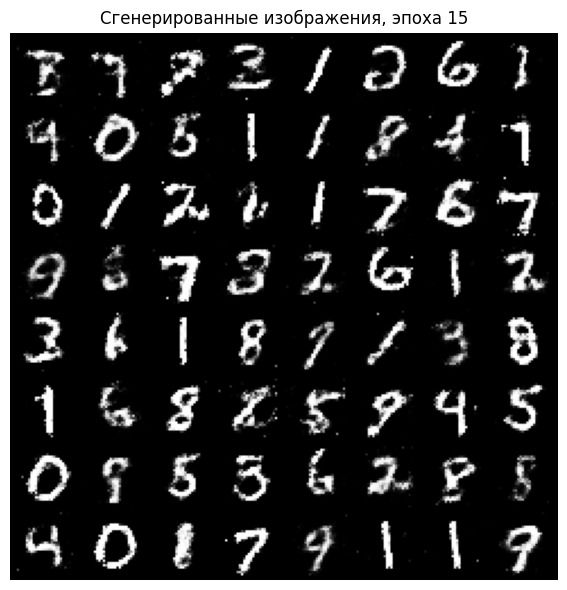

In [8]:
def train_gan(num_epochs):
    G.train()
    D.train()

    loss_history_G = []
    loss_history_D = []

    for epoch in range(1, num_epochs + 1):
        epoch_loss_G = 0.0
        epoch_loss_D = 0.0
        n_batches = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # --- шаг дискриминатора ---
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # реал
            D_real = D(real_imgs)
            loss_D_real = criterion(D_real, real_labels)

            # фейк (detach, чтобы не обновлять G)
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z).detach()
            D_fake = D(fake_imgs)
            loss_D_fake = criterion(D_fake, fake_labels)

            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- шаг генератора ---
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z)
            D_fake_for_G = D(fake_imgs)
            loss_G = criterion(D_fake_for_G, real_labels)  # хотим метку 1 для фейков

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_loss_G += loss_G.item()
            epoch_loss_D += loss_D.item()
            n_batches += 1

        avg_loss_G = epoch_loss_G / n_batches
        avg_loss_D = epoch_loss_D / n_batches
        loss_history_G.append(avg_loss_G)
        loss_history_D.append(avg_loss_D)

        print(f"Эпоха {epoch}/{num_epochs} | loss_G={avg_loss_G:.4f}, loss_D={avg_loss_D:.4f}")

        # визуальный мониторинг качества генератора
        if epoch % 5 == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z).cpu()
            G.train()

            grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(6, 6))
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.axis("off")
            plt.title(f"Сгенерированные изображения, эпоха {epoch}")
            plt.tight_layout()
            plt.show()

    return loss_history_G, loss_history_D

num_epochs = 15  # в отчёте попробуйте другие значения и сравните
loss_G, loss_D = train_gan(num_epochs)

## 6. Графики лоссов генератора и дискриминатора

Посмотрим, как ведут себя лоссы G и D по эпохам.


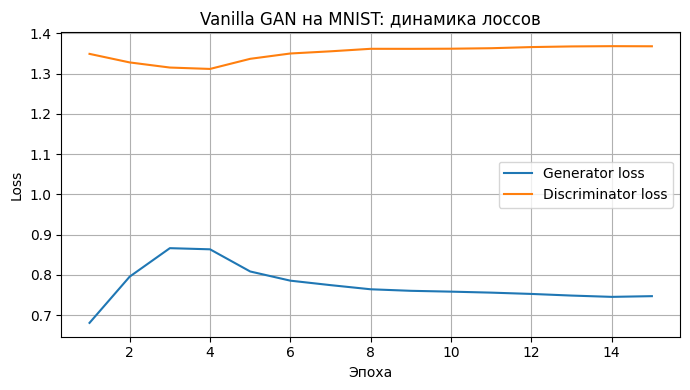

In [9]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, loss_G, label="Generator loss")
plt.plot(epochs_arr, loss_D, label="Discriminator loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Vanilla GAN на MNIST: динамика лоссов")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Анализ кривых лоссов

Опишите:
- есть ли тенденция к какому‑то «равновесию» между лоссами генератора и дискриминатора;  
- наблюдаются ли периодические колебания (кто «побеждает» на разных этапах обучения);  
- насколько реальное поведение лоссов совпало с вашими ожиданиями из раздела 1.


In [10]:
loss_comment = """По графику видно, что равновесия между лоссами генератора и дискриминатора нет.
Дискриминатор сразу держится в пределах 1, а после 20 эпохи совсем падает до 0.
Генератор в это время только растет, достигая к 30ой эпохе значение > 13, при этом имеет нестабильность.
Исходя из этого, можно сказать, что дискриминатор явно отличает реальные картинки от фейковых.

Периодического колебания не наблюдается.
Лосс генератора сразу идет вверх, имея настабильность, а лосс дискриминатор стабильно падает до 30ой эпохи.

Я думала, что между G и D будет хоть какой-то баланс, в итоге его нету.
Однако, я предполагала, что при сильно D - будет хуже G, тут так и получилось.
"""
print(loss_comment)

По графику видно, что равновесия между лоссами генератора и дискриминатора нет.
Дискриминатор сразу держится в пределах 1, а после 20 эпохи совсем падает до 0.
Генератор в это время только растет, достигая к 30ой эпохе значение > 13, при этом имеет нестабильность.
Исходя из этого, можно сказать, что дискриминатор явно отличает реальные картинки от фейковых.

Периодического колебания не наблюдается.
Лосс генератора сразу идет вверх, имея настабильность, а лосс дискриминатор стабильно падает до 30ой эпохи.

Я думала, что между G и D будет хоть какой-то баланс, в итоге его нету.
Однако, я предполагала, что при сильно D - будет хуже G, тут так и получилось.



## 7. Финальная генерация изображений и визуальная оценка

Сгенерируем новые изображения из случайного шума и посмотрим, насколько они похожи на реальный MNIST.


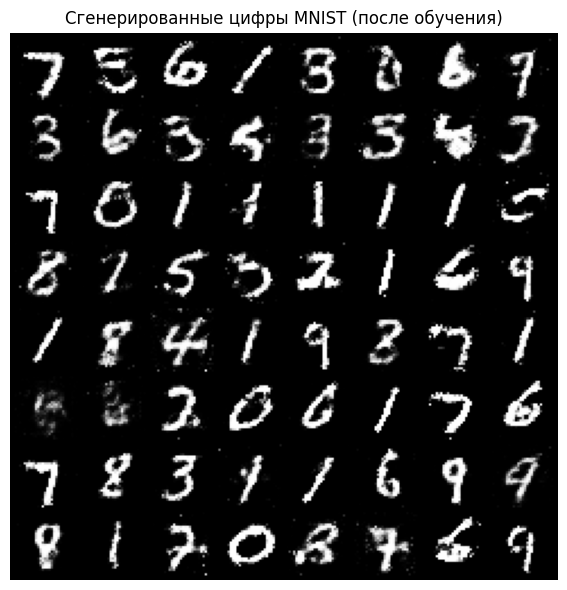

In [11]:
G.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim, device=device)
    gen_imgs = G(z).cpu()

grid = utils.make_grid(gen_imgs, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Сгенерированные цифры MNIST (после обучения)")
plt.tight_layout()
plt.show()

### Оценка качества сгенерированных цифр

Опишите:
- какие цифры получаются наиболее убедительными, а какие чаще всего выглядят как «шум» или гибриды;  
- встречаются ли явно «несуществующие» объекты, не похожие ни на одну цифру, и как часто;  
- как вы думаете, на что сильнее всего влияет качество: глубина сетей, размер `z_dim`, число эпох, баланс обучения G/D.


In [12]:
gen_quality_comment = """На сгенерированных изображениях во всех случаях один и тот же объект.
Предполагаю, что это связано с тем, что между генератором и дискриминатором нету баланса, возник так называемый mode collapse.
В данном случае я вижу, что на изображениях цифра 1 или 7.
Я думаю, что больше всего на качество влияют баланс обучения G/D.
"""
print(gen_quality_comment)

На сгенерированных изображениях во всех случаях один и тот же объект.
Предполагаю, что это связано с тем, что между генератором и дискриминатором нету баланса, возник так называемый mode collapse.
В данном случае я вижу, что на изображениях цифра 1 или 7.
Я думаю, что больше всего на качество влияют баланс обучения G/D.



## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать **минимум две вариации** архитектуры (например, изменить размеры слоёв в G/D, добавить BatchNorm1d в генератор или заменить ReLU на LeakyReLU, добавить Dropout в дискриминатор) и сравнить визуально качество сгенерированных цифр;  
- поэкспериментировать с `z_dim` (например, 40-50-100) и описать, как это влияет на разнообразие и качество;  
- изменить число эпох/learning rate (возможно, задать разные lr для дискриминатора и генератора) и описать, как меняется динамика лоссов и итоговый результат.

In [1]:
final_summary = """Я попробовала 2 варицации архитектуры, добавив BatchNorm1d в генератор и потом еще Dropout в дискриминатор.
После того, как я добавила BatchNorm1d в генератор процесс обучения очень хорошо стабилизировался.
Значения функций потерь стали близки к равновесным и практически не колеблются.
Это говорит о том, что генератор и дискриминатор находятся в сбалансированном состоянии.
Визуально качества изображений значительно улучшились: цифры стали четкими и различимыми.

При добавление Dropout в дискриминатор и использование функции потерь BCEWithLogitsLoss наблюдается постепенное уменьшение функции потерь генератора и рост функции потерь дискриминатора.
Это может говорить о том, что генератор начинает успешно “обманывать” дискриминатор.
Качество изображений остается хорошим и четким.

Второй эксперимент я производила с архитектурой с BatchNorm1d, без Dropout, но меняла z_dim на 50 и 150.
После увеличения размерности до 150 можно появляется рост разнообразия генерируемых изображений, однако качество ухудшается: изображения становятся более шумными.
Лоссы генератора стабильно снижаются, а у дискриминатора периодически колеблются.
Это может говорить о том, что генератору сложнее использовать высокоразмерное пространство.

При уменьшении размерности до 50 наблюдается примерно такое же качество как на размерности 100, то есть хорошее.
Можно сделать вывод, что для задачи на MNIST оптимальная размерность латентного вектора находится примерно в диапазоне 50–100.

В 3ьем эксперименте я меняла learning rate, чтобы у генератора и дискриминатора были разные значения: 1e-4 и 4e-4.
При увеличении скорости обучения дискриминатора относительно генератора наблюдается его доминирование, что затрудняет обучение генератора.
Генератор не успевает адаптироваться, а его функция потерь остаётся высокой.

При увеличении скорости обучения генератора относительно дискриминатора достигается более сбалансированное обучение.
Кривые loss_G и loss_D за все эпохи находятся примерно на одном и том же значении

Все эксперементы находятся в файле lab12_experimetns.ipynb
"""
print(final_summary)

Я попробовала 2 варицации архитектуры, добавив BatchNorm1d в генератор и потом еще Dropout в дискриминатор.
После того, как я добавила BatchNorm1d в генератор процесс обучения очень хорошо стабилизировался.
Значения функций потерь стали близки к равновесным и практически не колеблются.
Это говорит о том, что генератор и дискриминатор находятся в сбалансированном состоянии.
Визуально качества изображений значительно улучшились: цифры стали четкими и различимыми.

При добавление Dropout в дискриминатор и использование функции потерь BCEWithLogitsLoss наблюдается постепенное уменьшение функции потерь генератора и рост функции потерь дискриминатора.
Это может говорить о том, что генератор начинает успешно “обманывать” дискриминатор.
Качество изображений остается хорошим и четким.

Второй эксперимент я производила с архитектурой с BatchNorm1d, без Dropout, но меняла z_dim на 50 и 150.
После увеличения размерности до 150 можно появляется рост разнообразия генерируемых изображений, однако кач